# ENSAMBLE BINARIO

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
X_train =pd.read_parquet("data/X_train_completo.parquet")
X_test= pd.read_parquet("data/X_test_completo.parquet")
y_train=pd.read_parquet("data/y_train.parquet")
y_test=pd.read_parquet("data/y_test.parquet")

print(X_train.shape , X_test.shape , y_train.shape , y_test.shape)

(40257, 51) (17253, 51) (40257, 1) (17253, 1)


In [6]:
y_pred_svm = pd.read_csv("outputs/prediccion_binaria_svm.csv",index_col=0)
y_pred_rl = pd.read_csv("outputs/prediccion_binaria_rl.csv",index_col=0)
y_pred_tree = pd.read_csv("outputs/prediccion_binaria_tree.csv",index_col=0)

In [11]:
y_pred_total=pd.concat([y_pred_rl,y_pred_svm , y_pred_tree],axis=1)
y_pred_total

,pred_rl,pred_svm,pred_tree
14903,1,1,1
30335,1,1,1
52884,0,0,0
13872,0,0,0
6800,1,1,1
...,...,...,...
38717,0,0,0
21344,0,0,0
41455,1,1,1
53580,1,1,1


In [14]:
y_pred_total["pred_voting"]=y_pred_total.apply(lambda row : 1 if row.sum()> 1 else 0 , axis=1)
y_pred_total

,pred_rl,pred_svm,pred_tree,pred_voting
14903,1,1,1,1
30335,1,1,1,1
52884,0,0,0,0
13872,0,0,0,0
6800,1,1,1,1
...,...,...,...,...
38717,0,0,0,0
21344,0,0,0,0
41455,1,1,1,1
53580,1,1,1,1


In [20]:
from sklearn.metrics import accuracy_score,f1_score , recall_score , precision_score , roc_auc_score , confusion_matrix
print(f"recall score: {recall_score(y_test , y_pred_total['pred_voting'])}")
print(f"precision score: {precision_score(y_test , y_pred_total['pred_voting'])}")
print(f"f1score: {f1_score(y_test , y_pred_total['pred_voting'])}")
print(f"confusion matrix: \n{confusion_matrix(y_test , y_pred_total['pred_voting'])}")

recall score: 0.9172426676629927
precision score: 0.860120872383288
f1score: 0.8877638656601726
confusion matrix: 
[[4950 1597]
 [ 886 9820]]


<Axes: >

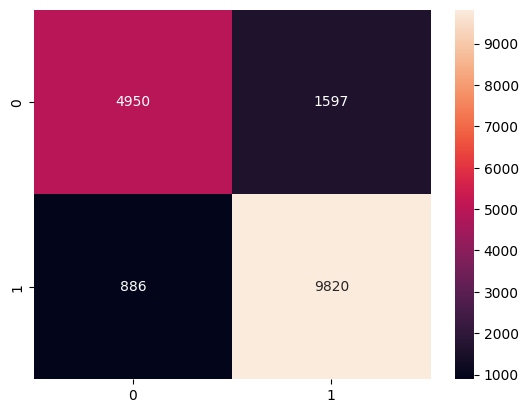

In [21]:
sns.heatmap(confusion_matrix(y_test , y_pred_total['pred_voting']),annot=True ,fmt='d')


In [22]:
y_pred_total.columns

Index(['pred_rl', 'pred_svm', 'pred_tree', 'pred_voting'], dtype='object')

In [29]:
from sklearn.metrics import recall_score, precision_score ,f1_score
recall_score_dict={}
precision_score_dict={}
f1_score_dict={}
for pred in y_pred_total.columns:
    print("**********************************")
    print(pred)

    recall  = recall_score(y_test , y_pred_total[pred])
    recall_score_dict[pred]=recall
    print(f"recall: {recall}")

    precision = precision_score(y_test , y_pred_total[pred])
    precision_score_dict[pred]=precision
    print(f"precision: {precision}")

    f1 = f1_score(y_test , y_pred_total[pred])
    f1_score_dict[pred]=f1
    print(f"f1: {f1}")





**********************************
pred_rl
recall: 0.9176162899308798
precision: 0.8594925634295713
f1: 0.8876039031441995
**********************************
pred_svm
recall: 0.9172426676629927
precision: 0.8595185995623632
f1: 0.8874429533233925
**********************************
pred_tree
recall: 0.9087427610685597
precision: 0.85507119001582
f1: 0.8810903821771419
**********************************
pred_voting
recall: 0.9172426676629927
precision: 0.860120872383288
f1: 0.8877638656601726


In [31]:
recall_score_dict

{'pred_rl': 0.9176162899308798,
 'pred_svm': 0.9172426676629927,
 'pred_tree': 0.9087427610685597,
 'pred_voting': 0.9172426676629927}

In [32]:
precision_score_dict

{'pred_rl': 0.8594925634295713,
 'pred_svm': 0.8595185995623632,
 'pred_tree': 0.85507119001582,
 'pred_voting': 0.860120872383288}

In [33]:
f1_score_dict

{'pred_rl': 0.8876039031441995,
 'pred_svm': 0.8874429533233925,
 'pred_tree': 0.8810903821771419,
 'pred_voting': 0.8877638656601726}

In [36]:
f1_score_dict.keys()

dict_keys(['pred_rl', 'pred_svm', 'pred_tree', 'pred_voting'])

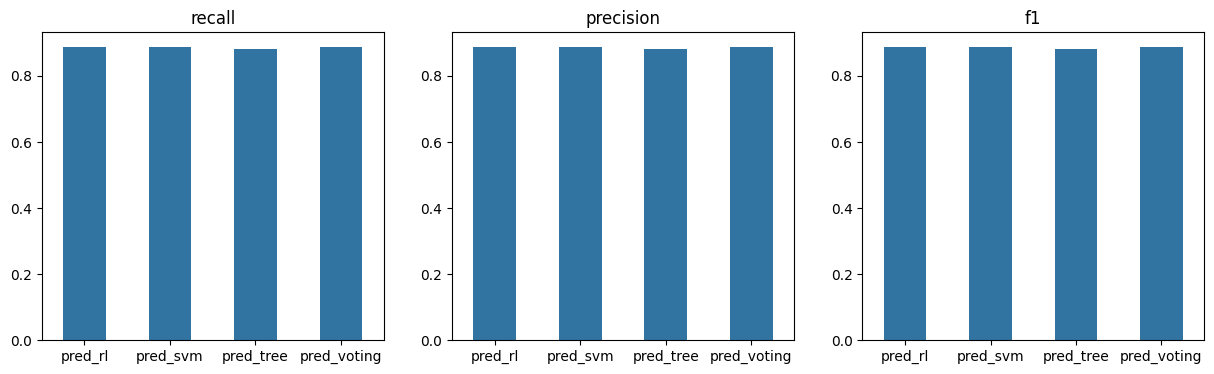

In [46]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
scores=[recall_score_dict , precision_score_dict , f1_score_dict]
names=["recall","precision","f1"]
for i,score_dict in enumerate(scores):
    ax=axes[i]
    sns.barplot(data=score_dict , x=score_dict.keys() , y=f1_score_dict.values(),ax=ax,width=0.5)
    ax.set_title(names[i])
plt.show()
